--- Auditing Data Availability: Unique Registrations per Month ---
Success! Historical audit chart saved at: ..\figuras\figure-historical-data-availability-en.pdf
Average active households per month: 15853.26


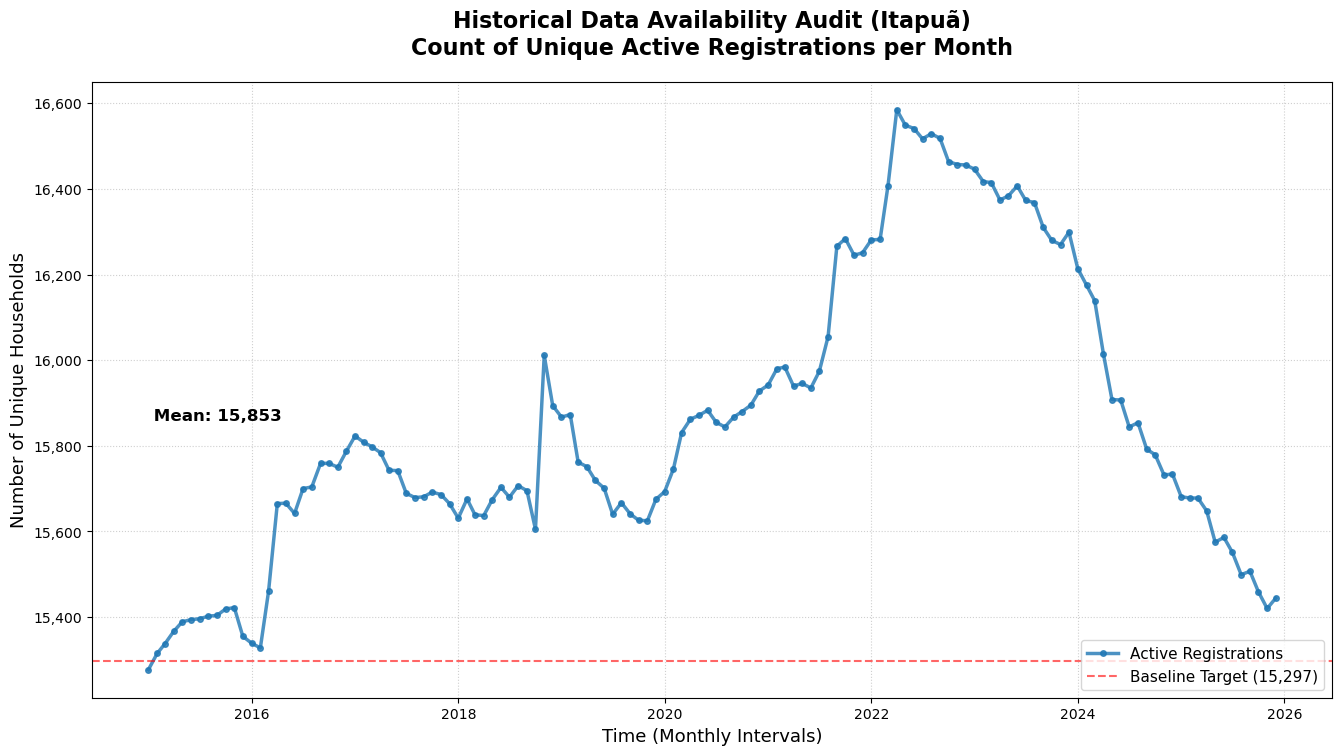

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 
HISTORY_FILE = 'Tabela_consumo_Itapua_120m.csv'
INPUT_DIR = os.path.join(BASE_PATH, 'includes','dados')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-historical-data-availability-en.pdf'

def main():
    print("--- Auditing Data Availability: Unique Registrations per Month ---")

    # ==========================================
    # 2. Data Loading and Processing
    # ==========================================
    path_history = os.path.join(INPUT_DIR, HISTORY_FILE)
    
    if not os.path.exists(path_history):
        print(f"Error: File not found at {path_history}")
        return

    # Load only necessary columns to save memory
    df = pd.read_csv(path_history, sep=';', usecols=['AM_REFERENCIA', 'SK_MATRICULA'])
    
    # Convert AM_REFERENCIA (YYYYMM) to Datetime
    df['Date'] = pd.to_datetime(df['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    
    # Group by Date and count unique matriculas
    # Note: .nunique() is used to ensure we count unique households per month
    monthly_counts = df.groupby('Date')['SK_MATRICULA'].nunique().reset_index()
    monthly_counts.columns = ['Date', 'Household_Count']

    # ==========================================
    # 3. Plotting (Scientific Standards)
    # ==========================================
    plt.figure(figsize=(16, 8))
    
    # Plotting the time series
    plt.plot(monthly_counts['Date'], monthly_counts['Household_Count'], 
             color='#1f77b4', linestyle='-', linewidth=2.5, 
             marker='o', markersize=4, alpha=0.8, label='Active Registrations')

    # Adding a reference line for the 15,297 baseline target
    plt.axhline(y=15297, color='red', linestyle='--', linewidth=1.5, 
                label='Baseline Target (15,297)', alpha=0.6)

    # Annotations for start, end, and global mean
    mean_val = monthly_counts['Household_Count'].mean()
    plt.text(monthly_counts['Date'].iloc[0], mean_val, f' Mean: {mean_val:,.0f}', 
             fontsize=12, color='black', fontweight='bold', va='bottom')

    # ==========================================
    # 4. Final Formatting
    # ==========================================
    plt.title('Historical Data Availability Audit (Itapuã)\n'
              'Count of Unique Active Registrations per Month', 
              fontsize=16, fontweight='bold', pad=20)
    
    plt.ylabel('Number of Unique Households', fontsize=13)
    plt.xlabel('Time (Monthly Intervals)', fontsize=13)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Format Y-axis with comma separator
    plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.legend(loc='lower right', fontsize=11, frameon=True)
    
    # Ensure directory exists and save
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Historical audit chart saved at: {save_path}")
    print(f"Average active households per month: {mean_val:.2f}")
    plt.show()

if __name__ == "__main__":
    main()